# Part 1: Retail Sales Pulse — Exploratory Data Analysis

## Business Objective

Analyze six months of retail transaction data to identify store performance,
category trends, temporal sales patterns, and unusual store-level revenue
behavior, and use these findings to support Q3 promotional decisions.

-----------------------------------------------------------------------------------------------------------------------------------

| Canvas Element          | Your Answer                                                                                                                                                                                                                                                                                                                                                                                     |
| ----------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Situation (S)**       | The retail chain has six months of historical sales data covering 12 stores and 5 product categories. Part 1 uses this historical CSV to understand store performance, category trends, time patterns, and anomalies. A weekly JSON API response is also available to provide the latest 7-day sales data.                                                                                      |
| **Complication (C)**    | The Operations Head does not have a single, timely view of current sales performance against historical trends. Decisions may rely on manual analysis or gut feel, and there is no automated process to validate weekly data, identify significant category declines, and highlight stores requiring attention.                                                                                 |
| **Question (Q)**        | Which stores and categories require operational attention based on their current performance, and is this week's sales performance consistent with the 6-month historical trend? The use case should answer this through historical analysis and automatically produce a validated weekly sales summary with alerts.                                                                            |
| **SSOT**                | **Part 1:** The historical CSV is the source of truth for the six-month baseline. **Part 2:** The weekly JSON API response is the source of truth for the current week's sales. The CSV provides the historical context, while the JSON provides the current live signal; the pipeline compares the two to determine whether current performance is abnormal.                                   |
| **Success Definition**  | **Part 1:** Successfully identify actionable sales insights, including the strongest/weakest stores, category trends, time patterns, and significant anomalies, leading to a specific business recommendation. **Part 2:** Successfully process the clean weekly API data, validate it, generate the required weekly aggregations and category alert, and complete the pipeline without errors. |
| **Primary Stakeholder** | **Head of Operations.** She needs to decide which stores or categories require attention, where promotional or operational effort should be focused, and whether the latest week's performance requires investigation. The weekly summary should be available every Monday morning to support these decisions.                                                                                  |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

Importing required files for Part 1, numpy and pandas used for data cleaning (EDA Process) and matplotlib, seaborn used for visualization of given observations.

In [2]:
# Part - 1: Retail Sales Pulse: Exploratory Data Analysis

# (1.) Load and inspect the data

df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")
print(df.columns)

Index(['transaction_id', 'date', 'store_id', 'store_city', 'category',
       'product_name', 'units_sold', 'unit_price', 'revenue', 'discount_pct'],
      dtype='str')


### Observation

The dataset was successfully loaded into a Pandas DataFrame. The dataset
contains the expected transaction-level retail sales information, including
transaction details, store information, product category, units sold,
pricing, revenue, and discount percentage.

The column structure matches the required fields specified for the analysis,
so the dataset is suitable for the planned exploratory data analysis.

In [3]:
df.head()

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.46,5843.37,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.06,11598.06,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.37,15493.60,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.28,9351.65,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.14,1917.14,0


### Observation

The first five records provide an initial view of the structure and values
contained in the dataset. Each row represents a retail transaction, with
information about the transaction date, store, category, product, quantity,
price, revenue, and discount.

In [4]:
df.tail()

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
107831,TXN107832,2026-06-30,S12,Kakinada,Personal Care,Shampoo,4,803.64,3214.56,0
107832,TXN107833,2026-06-30,S12,Kakinada,Personal Care,Body Lotion,2,288.41,547.98,5
107833,TXN107834,2026-06-30,S12,Kakinada,Personal Care,Shampoo,2,808.72,1536.57,5
107834,TXN107835,2026-06-30,S12,Kakinada,Personal Care,Face Wash,5,237.13,1185.65,0
107835,TXN107836,2026-06-30,S12,Kakinada,Personal Care,Face Wash,1,921.75,783.49,15


### Observation

.tail() provides last five records of given dataset. Each row represents a retail transaction, with
information about the transaction date, store, category, product, quantity,
price, revenue, and discount.

In [5]:
df.shape

(107836, 10)

### Observation 

df.shape provides exact number of rows and columns in the dataset. dataset is with 1,07,836 rows and 10 columns. 

In [6]:
df.dtypes

transaction_id        str
date                  str
store_id              str
store_city            str
category              str
product_name          str
units_sold          int64
unit_price        float64
revenue           float64
discount_pct        int64
dtype: object

### Observation

df.dtypes provides data types of columns. The dataset contains a combination of categorical, identifier, date, and
numeric columns. The transaction, store, and product-related fields are
stored as strings, while `units_sold`, `unit_price`, `revenue`, and
`discount_pct` are stored as numeric data types suitable for calculations.

The `date` column is currently stored as a string (`str`). Since the later
analysis requires monthly and day-of-week analysis, it should be converted
to the datetime data type before performing time-based analysis.

In [7]:
# Converting the date column to datetime format

df["date"] = pd.to_datetime(df["date"])

print(df["date"].dtype)
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

datetime64[us]
Start date: 2026-01-01 00:00:00
End date: 2026-06-30 00:00:00


### Date Validation

The `date` column was converted from string format to datetime format using pd.to_datetime(), to
support time-based analysis.

The dataset covers the period from January 1, 2026 to June 30, 2026,
which represents the expected six-month historical period.

In [8]:
df.isnull().sum()

transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        0
unit_price        0
revenue           0
discount_pct      0
dtype: int64

### Observation

The missing-value check shows that all 10 columns contain 0 null values.
Therefore, the dataset does not require any missing-value treatment at this
stage.

This is beneficial because missing values will not directly affect the
upcoming calculations and aggregations for units sold, unit price, revenue,
and discount percentage.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 107836 entries, 0 to 107835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   transaction_id  107836 non-null  str           
 1   date            107836 non-null  datetime64[us]
 2   store_id        107836 non-null  str           
 3   store_city      107836 non-null  str           
 4   category        107836 non-null  str           
 5   product_name    107836 non-null  str           
 6   units_sold      107836 non-null  int64         
 7   unit_price      107836 non-null  float64       
 8   revenue         107836 non-null  float64       
 9   discount_pct    107836 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(2), str(5)
memory usage: 12.2 MB


df.info() provides basic information  of entire table regarding null values, data types.

In [10]:
df.describe()

,date,units_sold,unit_price,revenue,discount_pct
count,107836,107836.000000,107836.000000,107836.000000,107836.000000
mean,2026-04-01 18:11:48.275529,2.583488,1778.097787,4263.920924,7.228152
min,2026-01-01 00:00:00,1.000000,50.020000,40.040000,0.000000
25%,2026-02-15 00:00:00,1.000000,274.827500,467.772500,0.000000
50%,2026-04-02 00:00:00,2.000000,488.450000,1034.615000,5.000000
75%,2026-05-17 00:00:00,3.000000,1039.522500,2473.335000,10.000000
max,2026-06-30 00:00:00,13.000000,44990.140000,355090.880000,20.000000
std,NaN,1.471616,5053.631792,14243.244169,6.730445


### Observation - 1 

### Business Observation 1

The mean revenue (4,263.92) is significantly higher than the median revenue
(1,034.62) declared at 50%. This indicates that revenue is likely right-skewed, with a
relatively small number of high-value transactions contributing
significantly to the overall average.

Therefore, both mean and median should be considered when interpreting typical transaction revenue.

### Observation 2 — Unit Price / Revenue variation 

The dataset shows substantial variation in unit price and revenue. The
maximum unit price (44,990.14) and maximum revenue (355,090.88) are much
higher than their respective medians.

These extreme values may represent genuine high-value products or
transactions, but they should be investigated during the outlier analysis
before deciding whether any treatment is required.

In [11]:
df.duplicated().sum()                            # Checks whether the entire row is duplicated.

np.int64(0)

### Duplicate Row Check

The dataset contains 0 completely duplicated rows. Therefore, no duplicate
records need to be removed at the row level.

In [12]:
df["transaction_id"].duplicated().sum()          # Checks whether the transaction identifier occurs more than once.

np.int64(0)

### Transaction ID Check

The `transaction_id` column contains 0 duplicated values, indicating that
each transaction has a unique identifier.

In [13]:
# Business-rule validation

print("Units sold <= 0:", (df["units_sold"] <= 0).sum())
print("Unit price <= 0:", (df["unit_price"] <= 0).sum())
print("Revenue <= 0:", (df["revenue"] <= 0).sum())
print("Discount < 0:", (df["discount_pct"] < 0).sum())
print("Discount > 100:", (df["discount_pct"] > 100).sum())

Units sold <= 0: 0
Unit price <= 0: 0
Revenue <= 0: 0
Discount < 0: 0
Discount > 100: 0


### Business Rule Validation

The numerical fields were checked against basic business rules.

- `units_sold` contains no values less than or equal to 0.
- `unit_price` contains no values less than or equal to 0.
- `revenue` contains no values less than or equal to 0.
- `discount_pct` contains no negative values.
- `discount_pct` contains no values greater than 100%.

In [14]:
# 5.2 — Revenue by Store 

store_revenue = df.groupby("store_id")["revenue"].sum().sort_values(ascending=False)
print(store_revenue)

store_id
S01    59055493.38
S03    53175162.00
S07    48537659.56
S06    44969840.50
S02    42069856.33
S04    41379797.16
S08    35032561.12
S09    33452441.09
S11    32780138.71
S05    25157347.02
S10    22217399.05
S12    21976480.86
Name: revenue, dtype: float64


### Observation

The top three stores based on total revenue are S01, S03, and S07 and stores with lowest revenue are S12, S10 and S05. I have performed group by function using "store_id" and selected revenue column, to perform sum() which perform summation on all values in revenue column for each store. Values are sorted from high to low, using .sort_values(ascending=False).

In [15]:
# General verification of the top 3 stores by revenue
top_3_stores = store_revenue.nlargest(3)
print("Top 3 stores by revenue:")
print(top_3_stores)
print("-----------------------------------------------")
bottom_3_stores = store_revenue.nsmallest(3)
print("Bottom 3 stores by revenue:")
print(bottom_3_stores)

Top 3 stores by revenue:
store_id
S01    59055493.38
S03    53175162.00
S07    48537659.56
Name: revenue, dtype: float64
-----------------------------------------------
Bottom 3 stores by revenue:
store_id
S12    21976480.86
S10    22217399.05
S05    25157347.02
Name: revenue, dtype: float64


In [16]:
# color selection for the bar chart based on revenue ranking
colors = []

for i in range(len(store_revenue)):
    if i < 3:
        colors.append("green")              # Top 3
    elif i >= len(store_revenue) - 3:
        colors.append("red")                # Bottom 3
    else:
        colors.append("gray")               # Middle 6

According to given question, to differentiate top 3 and bottom 3, colors should be assaigned according to the index value. 

index - 0 to 2 will get green, index of last three will get red, remaining as gray.

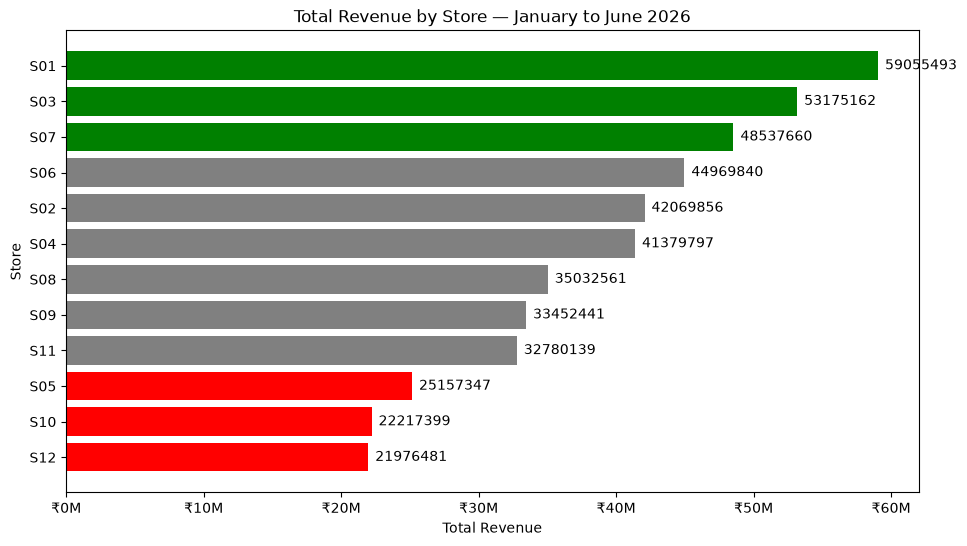

In [17]:
# Horizontal bar chart for revenue by store

from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    store_revenue.index,
    store_revenue.values,
    color=colors
)                                           # barh() creates a horizontal bar chart.

ax.bar_label(bars, fmt="%.0f", label_type="edge", padding=5, fontsize=10)
ax.set_xlabel("Total Revenue")
ax.set_ylabel("Store")
ax.set_title("Total Revenue by Store — January to June 2026")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/1e6:.0f}M")
)

plt.gca().invert_yaxis()                  # Invert the y-axis to have the highest revenue store at the top.

plt.show()

### Observation

S01 is the highest-performing store with ₹59.06M in total revenue, while
S12 is the lowest with ₹21.98M, showing a substantial performance gap
across stores. The operations team should investigate differences in local
demand, product mix, and store-level sales activity to understand the
drivers of this variation and identify opportunities for improvement.

In [18]:
# 5.3 Category Performance Over Time

# Step 1 — Prepare monthly revenue by category 

df["month"] = df["date"].dt.to_period("M").astype(str)

category_monthly = (
    df.groupby(["month", "category"])["revenue"]
      .sum()
      .reset_index()
)

category_monthly

,month,category,revenue
0,2026-01,Apparel,10049916.78
1,2026-01,Electronics,45686596.63
2,2026-01,Grocery,7307011.34
3,2026-01,Home & Kitchen,15130871.54
4,2026-01,Personal Care,6593734.81
5,2026-02,Apparel,9510938.10
6,2026-02,Electronics,38988602.50
7,2026-02,Grocery,6534957.35
8,2026-02,Home & Kitchen,13006413.31
9,2026-02,Personal Care,5792754.97


From date column, each month is selected and performed grouping function to gether with month, category for revenue. Output shows, in each month, for each category, how much revenue was generated. As, sum() is performed, total revenue of each category in each month is displayed. 

In [19]:
# Step 2 — Better structure for plotting

category_trend = category_monthly.pivot(                  # pivot() reshapes the DataFrame to have months as rows and categories as columns, with revenue as values.
    index="month",
    columns="category",
    values="revenue"
)

category_trend

category,Apparel,Electronics,Grocery,Home & Kitchen,Personal Care
month,,,,,
2026-01,10049916.78,45686596.63,7307011.34,15130871.54,6593734.81
2026-02,9510938.10,38988602.50,6534957.35,13006413.31,5792754.97
2026-03,11540439.47,40846509.47,7132787.06,14362119.50,6808029.34
2026-04,11681806.66,37092265.09,7047399.58,13431147.66,6417868.13
2026-05,13219535.79,34226926.43,7232706.20,13581886.25,7298818.71
2026-06,13476952.88,29686824.81,7047719.23,12333283.07,6737354.12


### Observation

The aggregated data was reshaped so that each row represents a month and
each column represents a product category. This structure makes the data
suitable for plotting and comparing the monthly revenue trends of all five
categories on a single chart.

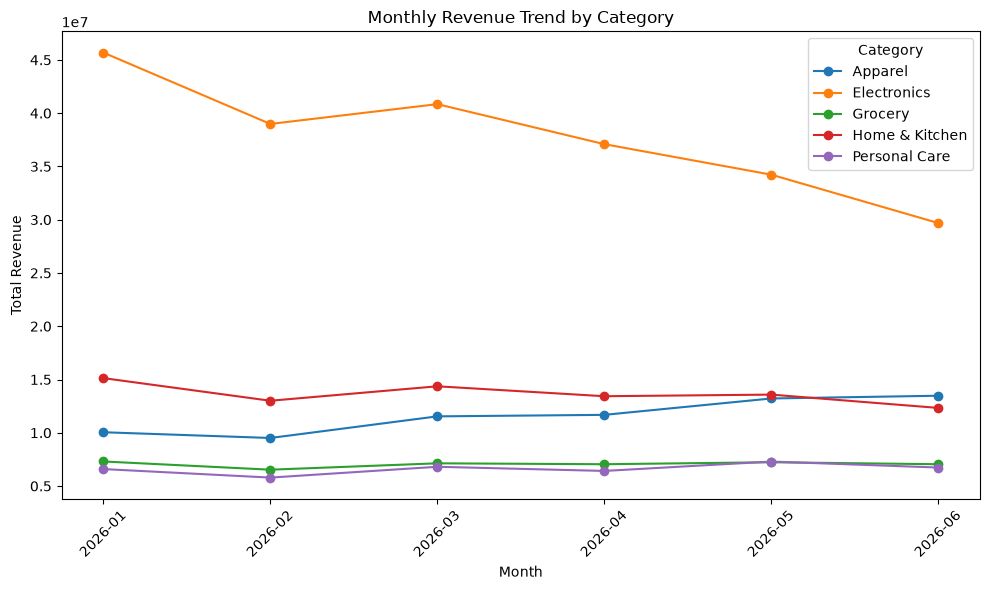

In [20]:
# Step 3 — Matplotlib line chart

fig, ax = plt.subplots(figsize=(10, 6))

for category in category_trend.columns:
    ax.plot(
        category_trend.index,
        category_trend[category],
        marker="o",
        label=category
    )

ax.set_title("Monthly Revenue Trend by Category")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue")
ax.legend(title="Category")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The line chart compares the monthly revenue movement of all five
categories from January through June 2026. The chart makes differences in
growth, decline, and month-to-month stability across categories visually
clear and provides a basis for identifying the strongest changes in
performance.

In [21]:
# Step 4 — Identify the steepest decline

# January → June.

category_change = (
    category_trend.iloc[-1] - category_trend.iloc[0]
).sort_values()

category_change

category
Electronics      -15999771.82
Home & Kitchen    -2797588.47
Grocery            -259292.11
Personal Care       143619.31
Apparel            3427036.10
dtype: float64

### Observation

The January-to-June revenue change was calculated for each category to
measure its overall movement during the six-month period. Negative values
represent a decline in revenue, while positive values represent an overall
increase.

In [22]:
# Step 5 — Identify Steepest Decline  

steepest_decline = category_change.idxmin()

steepest_decline

'Electronics'

### Observation

The category with the steepest January-to-June decline is **'Electronics'**.
This indicates that its revenue decreased more than the other categories
over the six-month period and therefore requires further investigation into
the factors affecting its sales performance.

In [23]:
# Step 6 — Calculate Stability 

category_stability = category_trend.std().sort_values()               # Pandas calculates the standard deviation of each column.
category_stability

category
Grocery           2.726059e+05
Personal Care     4.969814e+05
Home & Kitchen    9.899583e+05
Apparel           1.607520e+06
Electronics       5.513101e+06
dtype: float64

### Observation

The standard deviation of monthly revenue was calculated for each
category to measure month-to-month variation. A lower standard deviation
indicates less variation in monthly revenue and therefore a more stable
revenue pattern.

In [24]:
# Step 7 — Identify Most Stable Category

most_stable = category_stability.idxmin()
most_stable

'Grocery'

### Observation

The category with the most stable monthly revenue is **Grocery**, as it
has the lowest variation in revenue across the six-month period. Its
relatively consistent performance may indicate steady demand compared with
the other categories.

In [25]:
# Step 8 — Create Final Summary Table

category_summary = pd.DataFrame({
    "January_Revenue": category_trend.iloc[0],
    "June_Revenue": category_trend.iloc[-1],
    "Change": category_change,
    "Monthly_Std": category_stability
})
category_summary

,January_Revenue,June_Revenue,Change,Monthly_Std
category,,,,
Apparel,10049916.78,13476952.88,3427036.10,1.607520e+06
Electronics,45686596.63,29686824.81,-15999771.82,5.513101e+06
Grocery,7307011.34,7047719.23,-259292.11,2.726059e+05
Home & Kitchen,15130871.54,12333283.07,-2797588.47,9.899583e+05
Personal Care,6593734.81,6737354.12,143619.31,4.969814e+05


### Business Interpretation

Electronics shows the steepest decline, falling by approximately ₹16.00M
from January to June, which may signal weakening demand, pricing pressure,
or changes in the product mix; the operations team should investigate
whether the decline is concentrated in specific products or stores.
Grocery is the most stable category, indicating relatively consistent
demand over the period, which raises the question of whether its successful
sales patterns or product mix can provide insights for improving the
underperforming categories.

In [26]:
# 5.4 Day-of-week and monthly patterns

# Day of the week 

# Step 1 — Extract Day of Week 

df["day_of_week"] = df["date"].dt.day_name()            # .dt.day_name() = Converts the datetime object to the corresponding day of the week as a string.

df[["date", "day_of_week"]]

,date,day_of_week
0,2026-01-01,Thursday
1,2026-01-01,Thursday
2,2026-01-01,Thursday
3,2026-01-01,Thursday
4,2026-01-01,Thursday
...,...,...
107831,2026-06-30,Tuesday
107832,2026-06-30,Tuesday
107833,2026-06-30,Tuesday
107834,2026-06-30,Tuesday


### Observation

The day of the week was extracted from the `date` column and stored in a
new `day_of_week` column. This enables revenue performance to be compared
across different weekdays and helps identify potential weekly sales patterns.

In [27]:
# Step 2 — Calculate Revenue for Each Actual Date 

daily_revenue = (
    df.groupby(["date", "day_of_week"])["revenue"]
      .sum()
      .reset_index()
)

daily_revenue.head(20) 

,date,day_of_week,revenue
0,2026-01-01,Thursday,1811086.82
1,2026-01-02,Friday,2846032.80
2,2026-01-03,Saturday,4214219.34
3,2026-01-04,Sunday,3122804.05
4,2026-01-05,Monday,1935902.72
5,2026-01-06,Tuesday,2542187.06
6,2026-01-07,Wednesday,2108883.32
7,2026-01-08,Thursday,2348967.40
8,2026-01-09,Friday,2492797.33
9,2026-01-10,Saturday,4100145.77


From whole data frame, i try to group both date and day with revenue and assigned to daily_revenue, as they were required columns. 

In [28]:
# Step 3 — Calculate Average Daily Revenue by Weekday 

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

avg_daily_revenue = (
    daily_revenue.groupby("day_of_week")["revenue"]
    .mean()
    .reindex(day_order)
)

avg_daily_revenue

day_of_week
Monday       2.012141e+06
Tuesday      2.054130e+06
Wednesday    2.228117e+06
Thursday     2.245493e+06
Friday       2.623612e+06
Saturday     3.523605e+06
Sunday       3.083375e+06
Name: revenue, dtype: float64

From daily_revenue df, i performed group by operation on indivudual day with revenue and mean() function to average the revenue of each day.

In [29]:
# Step 4 — Find Best and Worst Performing Day 

best_day = avg_daily_revenue.idxmax()
best_day_revenue = avg_daily_revenue.max()

worst_day = avg_daily_revenue.idxmin()
worst_day_revenue = avg_daily_revenue.min()

print("Best performing day:", best_day)
print("Average revenue:", best_day_revenue)
print("-----------------------------------------------")
print("Worst performing day:", worst_day)
print("Average revenue:", worst_day_revenue)

Best performing day: Saturday
Average revenue: 3523605.445
-----------------------------------------------
Worst performing day: Monday
Average revenue: 2012140.9634615383


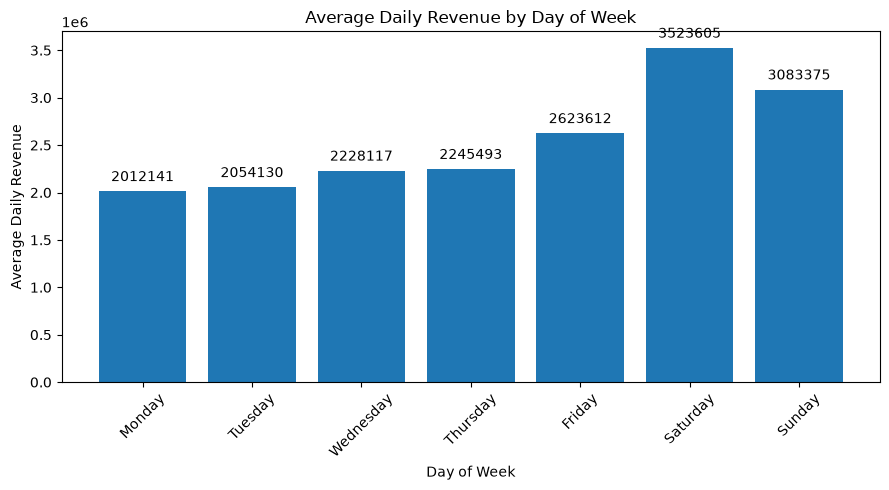

In [30]:
# Step 5 — Plot Average Daily Revenue by Day 

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    avg_daily_revenue.index,
    avg_daily_revenue.values
)

ax.bar_label(bars, fmt="%.0f", padding=5, fontsize=10)

ax.set_title("Average Daily Revenue by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Daily Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

According to graph, it is clearly evident that, `Saturday` is the best performing day, in terms of revenue with average of `3523605`. Where as, `Monday` is the lowest with average `2012141`.

In [31]:
# Monthly patterns 

# Step 6 — Total Revenue by Month 

monthly_revenue = (
    df.groupby("month")["revenue"]
      .sum()
)

monthly_revenue

month
2026-01    84768131.10
2026-02    73833666.23
2026-03    80689884.84
2026-04    75670487.12
2026-05    75559873.38
2026-06    69282134.11
Name: revenue, dtype: float64

### Observation

Revenue was aggregated by month to measure the total sales generated during
each month from January through June 2026.

In [32]:
# Step 7 — Best and Worst Performing Month 

best_month = monthly_revenue.idxmax()
best_month_revenue = monthly_revenue.max()

worst_month = monthly_revenue.idxmin()
worst_month_revenue = monthly_revenue.min()

print("Best performing month:", best_month)
print("Total revenue:", best_month_revenue)
print("-----------------------------------------------")
print("Worst performing month:", worst_month)
print("Total revenue:", worst_month_revenue)

Best performing month: 2026-01
Total revenue: 84768131.1
-----------------------------------------------
Worst performing month: 2026-06
Total revenue: 69282134.11


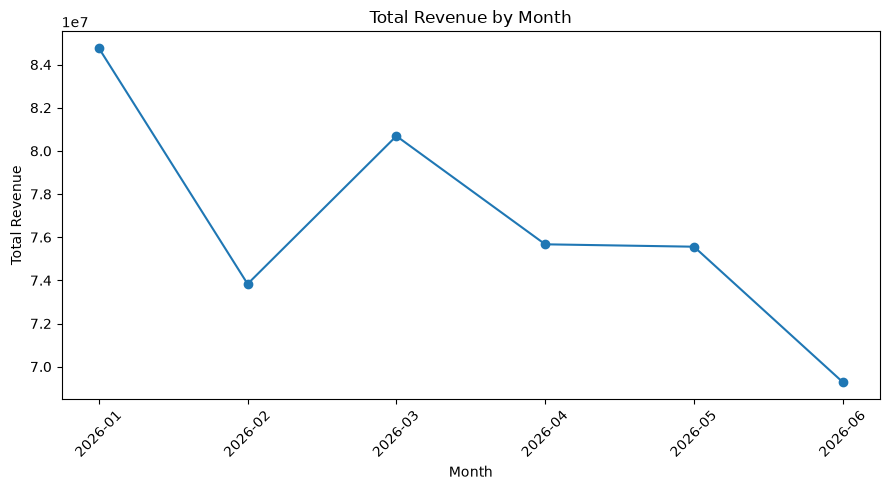

In [33]:
# Step 8 — Monthly Revenue Line Chart 

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

ax.set_title("Total Revenue by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From line graph, it clearly shows ` 2026-01 (January)` is highest in total revenue, where as `2026-06 (June)` is lowest in total revenue.

# Step 9 — Final Business Interpretation 

Saturday is the best-performing day, with an average daily revenue of approximately ₹35.24 lakh, while Monday is the weakest, at approximately ₹20.12 lakh. This indicates that customer demand is substantially higher toward the weekend, so the Operations Head should consider scheduling flash promotions and increasing inventory/staffing on Friday and Saturday to maximize sales opportunities.

January generated the highest total revenue at approximately ₹8.48 crore, while June recorded the lowest at approximately ₹6.93 crore. The declining monthly revenue trend, particularly the lower performance in June, suggests that the business should investigate the reasons for the recent slowdown, such as changes in customer demand, category performance, or promotional effectiveness.

Based on the observed patterns, flash promotions should primarily be scheduled on **Friday and Saturday**, with Saturday receiving the strongest promotional focus because it has the highest average daily revenue. The business should also investigate the decline from January to June before planning future campaigns.

In [34]:
# 5.5 Anomaly identification

# Step 1 — Create the week column 

df["week"] = df["date"].dt.to_period("W-SUN")
print(df[["date", "week"]].head())

        date                   week
0 2026-01-01  2025-12-29/2026-01-04
1 2026-01-01  2025-12-29/2026-01-04
2 2026-01-01  2025-12-29/2026-01-04
3 2026-01-01  2025-12-29/2026-01-04
4 2026-01-01  2025-12-29/2026-01-04


Using .dt.to_period("W-SUN"), we Converts the datetime object to a weekly period, with weeks starting on Sunday.

In [35]:
# Step 2 — Calculate weekly revenue per store 

weekly_store_revenue = (
    df.groupby(["store_id", "week"])["revenue"]
      .sum()
      .reset_index()
)

print(weekly_store_revenue.head(5))
print("-----------------------------------------------")
print(weekly_store_revenue.tail(5))

  store_id                   week     revenue
0      S01  2025-12-29/2026-01-04  1207561.87
1      S01  2026-01-05/2026-01-11  2350618.81
2      S01  2026-01-12/2026-01-18  2316840.47
3      S01  2026-01-19/2026-01-25  2579278.37
4      S01  2026-01-26/2026-02-01  2000527.75
-----------------------------------------------
    store_id                   week     revenue
319      S12  2026-06-01/2026-06-07  1068246.16
320      S12  2026-06-08/2026-06-14   963850.07
321      S12  2026-06-15/2026-06-21  1023998.72
322      S12  2026-06-22/2026-06-28   833905.05
323      S12  2026-06-29/2026-07-05   230159.76


### Observation

Weekly revenue was calculated separately for each store so that each store's performance can be compared against its own historical weekly pattern. This is important because stores have different normal revenue levels, so an anomaly should be identified relative to the individual store rather than the overall chain.

In [36]:
# Step 3 — Check whether each week contains 7 days

days_per_week = df.groupby("week")["date"].nunique()

print(days_per_week.head(3))
print("-----------------------------------------------")
print(days_per_week.tail(3))

week
2025-12-29/2026-01-04    4
2026-01-05/2026-01-11    7
2026-01-12/2026-01-18    7
Freq: W-SUN, Name: date, dtype: int64
-----------------------------------------------
week
2026-06-15/2026-06-21    7
2026-06-22/2026-06-28    7
2026-06-29/2026-07-05    2
Freq: W-SUN, Name: date, dtype: int64


### Observation

Two weeks in given dataset are not having 7 days completely (2025-12-29/2026-01-04 with 4 days, 2026-06-29/2026-07-05 with 2 days). This  will bring inconsistency to analysis.

In [37]:
# Step 4 — Keep only complete weeks 

full_weeks = days_per_week[days_per_week == 7].index

weekly_store_revenue = weekly_store_revenue[weekly_store_revenue["week"].isin(full_weeks)]

weekly_store_revenue

,store_id,week,revenue
1,S01,2026-01-05/2026-01-11,2350618.81
2,S01,2026-01-12/2026-01-18,2316840.47
3,S01,2026-01-19/2026-01-25,2579278.37
4,S01,2026-01-26/2026-02-01,2000527.75
5,S01,2026-02-02/2026-02-08,2178007.52
...,...,...,...
318,S12,2026-05-25/2026-05-31,773458.93
319,S12,2026-06-01/2026-06-07,1068246.16
320,S12,2026-06-08/2026-06-14,963850.07
321,S12,2026-06-15/2026-06-21,1023998.72


### Observation

Only complete 7-day weeks were retained for anomaly detection. The final week contains only two days because the dataset ends on June 30, so including it would artificially reduce weekly revenue and could incorrectly classify every store as an anomaly.

In [38]:
# Step 5 — Calculate each store's average and standard deviation
store_stats = (
    weekly_store_revenue
    .groupby("store_id")["revenue"]
    .agg(["mean", "std"])
    .reset_index()
)

print(store_stats)

weekly_store_revenue = weekly_store_revenue.merge(
    store_stats,
    on="store_id",
    how="left"
)

   store_id          mean            std
0       S01  2.302970e+06  293995.108575
1       S02  1.627619e+06  226809.226710
2       S03  2.049074e+06  269100.872352
3       S04  1.598816e+06  228635.581011
4       S05  9.774069e+05  127113.547805
5       S06  1.741919e+06  267725.531989
6       S07  1.876781e+06  308258.987633
7       S08  1.334241e+06  177407.496556
8       S09  1.290915e+06  169966.407685
9       S10  8.671293e+05  163809.391223
10      S11  1.265018e+06  187360.917926
11      S12  8.525633e+05  147479.922338


We need both pieces of information in one DataFrame so that we can calculate:

Lower Threshold = Mean - 2 × Standard Deviation

Therefore, we merge them using store_id.

In [39]:
# Step 6 — Calculate the anomaly threshold 

weekly_store_revenue["lower_threshold"] = (
    weekly_store_revenue["mean"]
    - 2 * weekly_store_revenue["std"]
)

As given, More than 2 standard deviations below that store's own average weekly revenue.

The lower threshold is: Mean − 2 × Standard Deviation 

In [40]:
# Step 7 — Flag anomalies  

anomalies = weekly_store_revenue[
    weekly_store_revenue["revenue"]
    < weekly_store_revenue["lower_threshold"]
].copy() 

anomalies[["store_id", "week", "revenue", "mean", "std", "lower_threshold"]]

,store_id,week,revenue,mean,std,lower_threshold
44,S02,2026-05-18/2026-05-24,1173289.36,1.627619e+06,226809.226710,1.174000e+06
97,S04,2026-06-08/2026-06-14,1137480.32,1.598816e+06,228635.581011,1.141545e+06
105,S05,2026-02-09/2026-02-15,655732.19,9.774069e+05,127113.547805,7.231798e+05
238,S10,2026-04-06/2026-04-12,505536.54,8.671293e+05,163809.391223,5.395105e+05


### Anomaly Identification — Business Interpretation

Four store-week combinations were flagged as unusually low-performing because their weekly revenue fell more than two standard deviations below their respective store's average weekly revenue.

- **S02 (May 18–24):** Weekly revenue was ₹11.73 lakh, slightly below its anomaly threshold of ₹11.74 lakh. A possible reason is a **supply disruption** that reduced product availability.
- **S04 (June 8–14):** Weekly revenue was ₹11.37 lakh against a threshold of ₹11.42 lakh. **Competitor activity** may have diverted customers during this period.
- **S05 (February 9–15):** Weekly revenue was ₹6.56 lakh compared with a threshold of ₹7.23 lakh. A **local event** may have reduced customer footfall.
- **S10 (April 6–12):** Weekly revenue was ₹5.06 lakh against a threshold of ₹5.40 lakh. A **pricing issue** may have made products less competitive.

These are hypotheses rather than confirmed causes. Further investigation using inventory availability, local event information, competitor activity, and pricing data would be required to determine the actual reasons for these revenue drops.

### Final Business Interpretation

Four store-week combinations were identified as significant revenue anomalies: S02 during May 18–24, S04 during June 8–14, S05 during February 9–15, and S10 during April 6–12. These unusually low-performing weeks may indicate temporary business issues such as supply disruption, competitor activity, local events, or pricing problems. The Operations Head should investigate these specific store-weeks using inventory, pricing, competitor, and local-event data before taking corrective action. Since these are hypotheses rather than confirmed causes, further data is required to determine the actual reason behind each revenue drop.

### 5.6 Business Recommendation

The most important finding is that **Electronics has the steepest decline, falling by approximately ₹1.60 crore from January to June**, while stores such as **S12 generated only ₹2.20 crore compared with S01's ₹5.91 crore** over the six-month period. I recommend that the Operations Head investigate the causes of the Electronics decline and the performance gap at S12 before allocating Q3 promotional spend. Before making a final decision, I would want **store-level footfall, inventory availability, product-level pricing, competitor activity, and promotion data** to determine whether the decline is caused by demand, supply, pricing, or competition. The weekly anomaly analysis should also be used to investigate stores such as **S02, S04, S05, and S10**, where unusually low-performing weeks were detected.

In [41]:
# 5.7 Understand the JSON structure

import json 

with open("MUC01_Weekly_Sales_API_Response.json","r") as f:
    data = json.load(f)  

print(type(data))

print(data.keys())

<class 'dict'>
dict_keys(['status', 'request_id', 'generated_at', 'period', 'record_count', 'data'])


In [42]:
print(type(data["data"])) 

print(data["data"][0])

<class 'list'>
{'transaction_id': 'TXN103546', 'date': '2026-06-24', 'store_id': 'S01', 'store_city': 'Vijayawada', 'category': 'Electronics', 'product_name': 'Headphones', 'units_sold': 3, 'unit_price': 13899.23, 'revenue': 41697.69, 'discount_pct': 0}


### 1. What is the top-level structure of this JSON? What keys does it contain?

The top-level structure of the JSON is a **dictionary/object**. It contains six keys: `status`, `request_id`, `generated_at`, `period`, `record_count`, and `data`. These keys provide both information about the API response and the actual weekly sales data.

### 2. Where does the actual transaction data sit within the JSON?

The actual transaction data is stored inside the **`data` key**. It contains a list of transaction records, with each record represented as a dictionary containing details such as `transaction_id`, `date`, `store_id`, `category`, `product_name`, `units_sold`, `unit_price`, `revenue`, and `discount_pct`.

### 3. How would a real retail API use this structure to deliver weekly sales data to a downstream system?

A real retail API could return this JSON response every week, with the metadata describing the request, reporting period, and expected number of records, while the `data` section contains the actual sales transactions. A downstream system could read the response, verify the metadata and record count, extract the transaction records, and load them into a DataFrame or database for validation, analysis, and automated weekly reporting. 


In [43]:
# 5.8 — Ingest and Parse the API Response 

# Extract transaction records into a DataFrame

import pandas as pd

weekly_df = pd.DataFrame(data["data"])

weekly_df.head()

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN103546,2026-06-24,S01,Vijayawada,Electronics,Headphones,3,13899.23,41697.69,0
1,TXN103547,2026-06-24,S01,Vijayawada,Apparel,Formal Shirt,2,1470.83,2941.66,0
2,TXN103548,2026-06-24,S01,Vijayawada,Apparel,Saree,4,2706.78,10827.12,0
3,TXN103549,2026-06-24,S01,Vijayawada,Apparel,Saree,3,3257.93,9773.79,0
4,TXN103550,2026-06-24,S01,Vijayawada,Apparel,Jeans,1,2118.31,2118.31,0


Firstly we use data["data"], to extract the list of transaction dictionaries from the JSON and convert them into data frame using pd.dateFrame()

In [44]:
# Convert the date column to date time format. 

print(type(weekly_df["date"])) 
print("------------------------------------------------------------------------") 

weekly_df["date"] = pd.to_datetime(weekly_df["date"])
print(weekly_df["date"].dtype)

<class 'pandas.Series'>
------------------------------------------------------------------------
datetime64[us]


By using pd.to_datetime() function, series array converted to dataframe.

In [45]:
# Confirm the record count matches the record_count field in the JSON metadata. 

actual_count = len(weekly_df)
expected_count = data["record_count"]

print("Expected record count:", expected_count)
print("Actual record count:", actual_count)
print("Record count matches:", expected_count == actual_count)

Expected record count: 4291
Actual record count: 4291
Record count matches: True


Because the API may claim that it returned a certain number of records, but the actual response could contain fewer or more records due to an incomplete response, transmission problem, or other data issue.

In [46]:
# Print the period covered — from and to dates — from the meta datafields.

print("Period From:", data["period"]["from"])
print("Period To:", data["period"]["to"])

Period From: 2026-06-24
Period To: 2026-06-30


In [47]:
# Show the first 5 rows

print(weekly_df.head())

  transaction_id       date store_id  store_city     category  product_name  \
0      TXN103546 2026-06-24      S01  Vijayawada  Electronics    Headphones   
1      TXN103547 2026-06-24      S01  Vijayawada      Apparel  Formal Shirt   
2      TXN103548 2026-06-24      S01  Vijayawada      Apparel         Saree   
3      TXN103549 2026-06-24      S01  Vijayawada      Apparel         Saree   
4      TXN103550 2026-06-24      S01  Vijayawada      Apparel         Jeans   

   units_sold  unit_price   revenue  discount_pct  
0           3    13899.23  41697.69             0  
1           2     1470.83   2941.66             0  
2           4     2706.78  10827.12             0  
3           3     3257.93   9773.79             0  
4           1     2118.31   2118.31             0  


This displays the first five transaction records after ingestion and date conversion.

Why would a production pipeline always check that the record count in the metadata matches the actual records received?

(A.) A production pipeline checks that the **record count provided in the API metadata matches the actual number of records received** to ensure that no transactions were lost, duplicated, or incompletely received during data transfer. If the counts do not match, the pipeline can **stop before processing incorrect data**, preventing unreliable reports and business decisions.

In [48]:
# 5.9 Validate the data before processing

# Step 1 — Load the corrupt JSON 

with open("MUC01_Weekly_Sales_API_Corrupt.json","r") as f:
    corrupted_data = json.load(f) 

print(type(corrupted_data))
print(corrupted_data.keys())

<class 'dict'>
dict_keys(['status', 'request_id', 'generated_at', 'period', 'record_count', 'data'])


### Observation

The corrupt API response was successfully loaded as a Python dictionary. The response contains metadata along with the transaction records inside the `data` field.

In [49]:
# Step 2 — Extract Transaction Records 

corrupt_df = pd.DataFrame(corrupted_data["data"])

print(corrupt_df.shape)

(4291, 10)


pd.DataFrame() converts that list of dictionaries ffrom corrupted_data into a table, so we can perform validation using Pandas.

In [50]:
# Step 3 — Check for Null Values 

null_values = corrupt_df.isnull().sum()
print(null_values)

transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        1
unit_price        0
revenue           0
discount_pct      0
dtype: int64


### Observation:- 

Out of all records, unit_price column has only one null value.

In [51]:
corrupt_df[corrupt_df["units_sold"].isnull()]

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
12,TXN103558,2026-06-24,S01,Vijayawada,Apparel,Formal Shirt,NaN,2753.11,11012.44,0


### Observation

One null value was detected in `units_sold` at row 12, confirming a data-quality issue in the incoming API data.

In [52]:
# Step 4 — Check Negative Revenue 

negative_revenue = corrupt_df[corrupt_df["revenue"] <= 0]
print(negative_revenue)

  transaction_id        date store_id  store_city category product_name  \
5      TXN103551  2026-06-24      S01  Vijayawada  Apparel      T-Shirt   

   units_sold  unit_price  revenue  discount_pct  
5         3.0      556.42   -150.0             0  


### Observation

One invalid revenue value was detected at row 5, where revenue is -150.0 .

In [53]:
# Step 5 — Check Invalid Store IDs 

valid_stores = [f"S{i:02d}" for i in range(1, 13)]                                      # d: Specifies the data type as a decimal integer. 
                                                                                        # 2: Sets the minimum width of the output to 2 characters. 
                                                                                        # 0: Indicates that the padding character should be zero (placed before the width in the specifier).

invalid_stores = corrupt_df[~corrupt_df["store_id"].isin(valid_stores)]              #   ~ = Not (opposite of rows which are from s0 - s12)

print(invalid_stores)

   transaction_id        date store_id  store_city category product_name  \
20      TXN103566  2026-06-24      S99  Vijayawada  Grocery   Atta (5kg)   

    units_sold  unit_price  revenue  discount_pct  
20         2.0       576.7   1153.4             0  


### Observation

Three data-quality issues were detected: one null `units_sold` value, one negative revenue value, and one invalid `store_id` (`S99`).

In [54]:
# Step 6 — Create the Validation Function

# (1.) Adding Null value constraint

def validate_data(df):
    issues = 0

    print("Validation Summary")
    print("------------------")
    print("Total records checked:", len(df))

    # Check for null values
    nulls = df.isnull()

    for row, col in zip(*nulls.to_numpy().nonzero()):
        print(f"Null value found: row {row}, column: {df.columns[col]}")
        issues += 1

    print("Null values found:", nulls.sum().sum()) 

validate_data(corrupt_df)

Validation Summary
------------------
Total records checked: 4291
Null value found: row 12, column: units_sold
Null values found: 1


### Observation:- 

validate_data function is created with null value finding constarint and verfied with corrupt data, output is matched with our previous findings.

In [55]:
# (2.) Add Negative Revenue Check 


def validate_data(df):
    issues = 0

    print("Validation Summary")
    print("------------------")
    print("Total records checked:", len(df))

    # Check for null values
    nulls = df.isnull()

    for row, col in zip(*nulls.to_numpy().nonzero()):
        print(f"Null value found: row {row}, column: {df.columns[col]}")
        issues += 1

    print("Null values found:", nulls.sum().sum()) 

    # Check for negative or zero revenue
    negative_revenue = df[df["revenue"] <= 0]

    for row, value in negative_revenue["revenue"].items():
        print(f"Negative revenue found: row {row}, revenue: {value}")

    issues += len(negative_revenue)

    print("Negative revenue found:", len(negative_revenue))

validate_data(corrupt_df)

Validation Summary
------------------
Total records checked: 4291
Null value found: row 12, column: units_sold
Null values found: 1
Negative revenue found: row 5, revenue: -150.0
Negative revenue found: 1


### Observation:- 

Negative revenue found at row number 5, which is -150.0 matches with previous observation.

In [56]:
# (3.) Add Invalid Store ID Check  

def validate_data(df):
    issues = 0

    print("Validation Summary")
    print("------------------")
    print("Total records checked:", len(df))

    # Check for null values
    nulls = df.isnull()

    for row, col in zip(*nulls.to_numpy().nonzero()):
        print(f"Null value found: row {row}, column: {df.columns[col]}")
        issues += 1

    print("Null values found:", nulls.sum().sum()) 
    print("-------------------------------")

    # Check for negative or zero revenue
    negative_revenue = df[df["revenue"] <= 0]

    for row, value in negative_revenue["revenue"].items():
        print(f"Negative revenue found: row {row}, revenue: {value}")

    issues += len(negative_revenue)

    print("Negative revenue found:", len(negative_revenue))
    print("-------------------------------")
    
    # Check for invalid store IDs
    valid_stores = [f"S{i:02d}" for i in range(1, 13)]

    invalid_stores = df[~df["store_id"].isin(valid_stores)]

    for row, value in invalid_stores["store_id"].items():
        print(f"Invalid store ID found: row {row}, store_id: {value}")

    issues += len(invalid_stores)

    print("Invalid store IDs found:", len(invalid_stores))

validate_data(corrupt_df)

Validation Summary
------------------
Total records checked: 4291
Null value found: row 12, column: units_sold
Null values found: 1
-------------------------------
Negative revenue found: row 5, revenue: -150.0
Negative revenue found: 1
-------------------------------
Invalid store ID found: row 20, store_id: S99
Invalid store IDs found: 1


### Observation:- 

With adding, Check for invalid store IDs constraint, we got 1 invalid store as row 20, store_id S99. 

In [57]:
# Final Validation Status 

def validate_data(df):
    issues = 0

    print("Validation Summary")
    print("------------------")
    print("Total records checked:", len(df))

    # Check for null values
    nulls = df.isnull()

    for row, col in zip(*nulls.to_numpy().nonzero()):
        print(f"Null value found: row {row}, column: {df.columns[col]}")
        issues += 1

    print("Null values found:", nulls.sum().sum()) 
    print("-------------------------------")

    # Check for negative or zero revenue
    negative_revenue = df[df["revenue"] <= 0]

    for row, value in negative_revenue["revenue"].items():
        print(f"Negative revenue found: row {row}, revenue: {value}")

    issues += len(negative_revenue)

    print("Negative revenue found:", len(negative_revenue))
    print("-------------------------------")
    # Check for invalid store IDs
    valid_stores = [f"S{i:02d}" for i in range(1, 13)]

    invalid_stores = df[~df["store_id"].isin(valid_stores)]

    for row, value in invalid_stores["store_id"].items():
        print(f"Invalid store ID found: row {row}, store_id: {value}")

    issues += len(invalid_stores)

    print("Invalid store IDs found:", len(invalid_stores))
    print("-------------------------------") 

    # Final validation status
    if issues > 0:
        print(f"Status: FAILED — {issues} issues detected.")
        print("Pipeline halted.")
    else:
        print("Status: PASSED — No issues detected.")


validate_data(corrupt_df)

Validation Summary
------------------
Total records checked: 4291
Null value found: row 12, column: units_sold
Null values found: 1
-------------------------------
Negative revenue found: row 5, revenue: -150.0
Negative revenue found: 1
-------------------------------
Invalid store ID found: row 20, store_id: S99
Invalid store IDs found: 1
-------------------------------
Status: FAILED — 3 issues detected.
Pipeline halted.


### Observation

The corrupt API data failed validation because 3 data-quality issues were detected: `one null value`, `one negative revenue`, and `one invalid store ID`. The pipeline was therefore halted to prevent invalid data from being processed.

### Assaignment question 

(Q.) What should a well-designed pipeline do when it encounters corrupt data — stop completely, skip the bad rows, or fix them automatically? Justify your answer with one sentence.

(A.) A well-designed pipeline should **stop completely when critical corrupt data is detected**, because processing invalid data can lead to incorrect analysis and business decisions.

In [58]:
# 5.10 Transform and aggregate 

# Step 1 — Use the Clean JSON DataFrame 

print(weekly_df.head())

  transaction_id       date store_id  store_city     category  product_name  \
0      TXN103546 2026-06-24      S01  Vijayawada  Electronics    Headphones   
1      TXN103547 2026-06-24      S01  Vijayawada      Apparel  Formal Shirt   
2      TXN103548 2026-06-24      S01  Vijayawada      Apparel         Saree   
3      TXN103549 2026-06-24      S01  Vijayawada      Apparel         Saree   
4      TXN103550 2026-06-24      S01  Vijayawada      Apparel         Jeans   

   units_sold  unit_price   revenue  discount_pct  
0           3    13899.23  41697.69             0  
1           2     1470.83   2941.66             0  
2           4     2706.78  10827.12             0  
3           3     3257.93   9773.79             0  
4           1     2118.31   2118.31             0  


### Observation

The clean weekly transaction data is ready for transformation and aggregation after successfully passing the validation stage.

In [59]:
# Step 2: Calculate Weekly Revenue by Store 

weekly_store_revenue = (
    weekly_df.groupby("store_id")["revenue"]
    .sum()
)

print(weekly_store_revenue) 
print("----------------------------------------")
top_store = weekly_store_revenue.idxmax()
top_store_revenue = weekly_store_revenue.max()

print("Top-performing store:", top_store)
print("Weekly revenue:", top_store_revenue)

store_id
S01    1608043.08
S02    1218330.60
S03    2037560.19
S04    1285265.18
S05     941961.76
S06    1565006.35
S07    1349795.33
S08    1269260.54
S09     976322.30
S10     627119.87
S11    1249928.27
S12     886816.81
Name: revenue, dtype: float64
----------------------------------------
Top-performing store: S03
Weekly revenue: 2037560.19


### Observation:- 

S03 is the top-performing store for the current API week with ₹20.38 lakh revenue. 

S10 is the lowest-performing store with ₹6.27 lakh.

This is specifically for June 24–30-2026 given in JSON API, not the entire six-month period.

In [60]:
# Step 3: Weekly Revenue by Category

weekly_revenue_by_category = (
    weekly_df.groupby("category")["revenue"]
    .sum()
)

print(weekly_revenue_by_category)
print("------------------------------------")
top_category = weekly_revenue_by_category.idxmax()
top_category_revenue = weekly_revenue_by_category.max()

print("Top-performing category:", top_category)
print("Weekly revenue:", top_category_revenue)

category
Apparel           3228573.10
Electronics       5764693.85
Grocery           1617278.70
Home & Kitchen    2847057.00
Personal Care     1557807.63
Name: revenue, dtype: float64
------------------------------------
Top-performing category: Electronics
Weekly revenue: 5764693.85


### Observation:- 

Electronics is the highest-revenue category this week at approximately ₹57.65 lakh.

Personal Care is the lowest at approximately ₹15.58 lakh.

In [61]:
# step - 4: 3. Highest-revenue store — top_store_this_week 

top_store_this_week = {
    "store_id": weekly_store_revenue.idxmax(),
    "revenue": weekly_store_revenue.max()
}

print(top_store_this_week)

{'store_id': 'S03', 'revenue': np.float64(2037560.19)}


### Observation:- 

The highesr revenue store is S03, with revenue 2037560.19

In [62]:
# step - 5: Category_alert  

# Historical 6-month daily average revenue by category
historical_daily_category_avg = (
    df.groupby(["date", "category"])["revenue"]
    .sum()
    .groupby("category")
    .mean()
)

# Current week's daily average revenue by category
current_daily_category_avg = (
    weekly_revenue_by_category / 7
)

# Calculate percentage difference
category_comparison = pd.DataFrame({
    "Current_Daily_Avg": current_daily_category_avg,
    "Historical_Daily_Avg": historical_daily_category_avg
})

category_comparison["Change_Pct"] = (
    (category_comparison["Current_Daily_Avg"]
     - category_comparison["Historical_Daily_Avg"])
    / category_comparison["Historical_Daily_Avg"]
) * 100

# Select categories more than 20% below historical average
category_alert = category_comparison[
    category_comparison["Change_Pct"] < -20
]

print(category_alert)

             Current_Daily_Avg  Historical_Daily_Avg  Change_Pct
category                                                        
Electronics      823527.692857          1.251534e+06  -34.198557


### Observation

The weekly pipeline successfully combines the current 7-day API data with the 6-month historical CSV data to provide meaningful category alerts. S03 was the highest-revenue store this week with approximately ₹20.38 lakh, while Electronics generated the highest category revenue at approximately ₹57.65 lakh. However, Electronics was approximately 34.20% below its historical 6-month daily average, triggering an ALERT because the decline exceeded the 20% threshold. This demonstrates how historical data from Part 1 can be used as a baseline to evaluate current weekly performance in Part 2.

In [63]:
# 5.11 Pipeline summary output

# Step 1 — Load and Prepare the JSON Data 

import json
import pandas as pd

def generate_weekly_summary(json_file):

    # Load JSON file
    with open(json_file, "r") as f:
        data = json.load(f)

    # Extract transaction records
    weekly_df = pd.DataFrame(data["data"])

    # Convert date to datetime
    weekly_df["date"] = pd.to_datetime(weekly_df["date"])

    print("JSON data loaded successfully.")
    print("Records:", len(weekly_df))

### Observation

The clean JSON file was successfully loaded and the transaction records were converted into a Pandas DataFrame. The date field was converted to datetime format so that the weekly sales data can be processed and analyzed correctly.

In [64]:
# Step 2 — Calculate Weekly Store Performance 

def generate_weekly_summary(json_file):

    with open(json_file, "r") as f:
        data = json.load(f)

    weekly_df = pd.DataFrame(data["data"])
    weekly_df["date"] = pd.to_datetime(weekly_df["date"])

    # Step 2: Store performance
    weekly_revenue_by_store = (
        weekly_df.groupby("store_id")["revenue"]
        .sum()
        .sort_values(ascending=False)
    )

    top_store_id = weekly_revenue_by_store.idxmax()
    top_store_revenue = weekly_revenue_by_store.max()

    bottom_store_id = weekly_revenue_by_store.idxmin()
    bottom_store_revenue = weekly_revenue_by_store.min()

    store_city = weekly_df.groupby("store_id")["store_city"].first()

    print("Top store:", top_store_id, "-", store_city[top_store_id])
    print("Top revenue:", top_store_revenue)

    print("Bottom store:", bottom_store_id, "-", store_city[bottom_store_id])
    print("Bottom revenue:", bottom_store_revenue)


generate_weekly_summary(
    "MUC01_Weekly_Sales_API_Response.json"
)

Top store: S03 - Guntur
Top revenue: 2037560.19
Bottom store: S10 - Nellore
Bottom revenue: 627119.87


### Observation

Weekly revenue was aggregated at store level to identify the strongest and weakest performing stores during the current 7-day period. S03 generated the highest weekly revenue at approximately ₹20.38 lakh, while S10 generated the lowest at approximately ₹6.27 lakh.

In [65]:
# Step 3 — Calculate Weekly Category Performance 

def generate_weekly_summary(json_file):

    # Step 2: Store performance
    weekly_revenue_by_store = (
        weekly_df.groupby("store_id")["revenue"]
        .sum()
        .sort_values(ascending=False)
    )

    top_store_id = weekly_revenue_by_store.idxmax()
    top_store_revenue = weekly_revenue_by_store.max()

    bottom_store_id = weekly_revenue_by_store.idxmin()
    bottom_store_revenue = weekly_revenue_by_store.min()

    store_city = weekly_df.groupby("store_id")["store_city"].first()

    print("Top store:", top_store_id, "-", store_city[top_store_id])
    print("Top revenue:", top_store_revenue)

    print("Bottom store:", bottom_store_id, "-", store_city[bottom_store_id])
    print("Bottom revenue:", bottom_store_revenue) 

    #-------------------- 

    # Step 3: Category Performance
    weekly_revenue_by_category = (
        weekly_df.groupby("category")["revenue"]
        .sum()
        .sort_values(ascending=False)
    )

    print("\nWeekly Revenue by Category:")
    print(weekly_revenue_by_category)

generate_weekly_summary(
    "MUC01_Weekly_Sales_API_Response.json"
)

Top store: S03 - Guntur
Top revenue: 2037560.19
Bottom store: S10 - Nellore
Bottom revenue: 627119.87

Weekly Revenue by Category:
category
Electronics       5764693.85
Apparel           3228573.10
Home & Kitchen    2847057.00
Grocery           1617278.70
Personal Care     1557807.63
Name: revenue, dtype: float64


### Observation

The current week's category revenue was compared against the historical 6-month daily average from the CSV dataset. This comparison provides a historical baseline for determining whether a category's current performance is significantly weaker than its normal performance.

In [66]:
# Step 4 — Identify Category Alerts 


def generate_weekly_summary(json_file):

    # Step 2: Store performance
    weekly_revenue_by_store = (
        weekly_df.groupby("store_id")["revenue"]
        .sum()
        .sort_values(ascending=False)
    )

    top_store_id = weekly_revenue_by_store.idxmax()
    top_store_revenue = weekly_revenue_by_store.max()

    bottom_store_id = weekly_revenue_by_store.idxmin()
    bottom_store_revenue = weekly_revenue_by_store.min()

    store_city = weekly_df.groupby("store_id")["store_city"].first()

    print("Top store:", top_store_id, "-", store_city[top_store_id])
    print("Top revenue:", top_store_revenue)

    print("Bottom store:", bottom_store_id, "-", store_city[bottom_store_id])
    print("Bottom revenue:", bottom_store_revenue) 

    #-------------------- 

    # Step 3: Category Performance
    weekly_revenue_by_category = (
        weekly_df.groupby("category")["revenue"]
        .sum()
        .sort_values(ascending=False)
    )

    print("\nWeekly Revenue by Category:")
    print(weekly_revenue_by_category)

    # -----------------------------

    # Step 4: Category Alert

    # Current week's average daily revenue
    current_daily_category_avg = (
        weekly_revenue_by_category / 7
    )

    # Historical 6-month daily average from CSV
    historical_daily_category_avg = (
        df.groupby(["date", "category"])["revenue"]
        .sum()
        .groupby("category")
        .mean()
    )

    # Compare current week with historical baseline
    category_comparison = pd.DataFrame({
        "Current_Daily_Avg": current_daily_category_avg,
        "Historical_Daily_Avg": historical_daily_category_avg
    })

    # Calculate percentage change
    category_comparison["Change_Pct"] = (
        (category_comparison["Current_Daily_Avg"]
         - category_comparison["Historical_Daily_Avg"])
        / category_comparison["Historical_Daily_Avg"]
    ) * 100

    # Categories more than 20% below historical baseline
    category_alert = category_comparison[
        category_comparison["Change_Pct"] < -20
    ]

    print("Category Comparison:")
    print(category_comparison)

    print("\nCategory Alert:")
    print(category_alert)


generate_weekly_summary(
    "MUC01_Weekly_Sales_API_Response.json"
)

Top store: S03 - Guntur
Top revenue: 2037560.19
Bottom store: S10 - Nellore
Bottom revenue: 627119.87

Weekly Revenue by Category:
category
Electronics       5764693.85
Apparel           3228573.10
Home & Kitchen    2847057.00
Grocery           1617278.70
Personal Care     1557807.63
Name: revenue, dtype: float64
Category Comparison:
                Current_Daily_Avg  Historical_Daily_Avg  Change_Pct
category                                                           
Apparel             461224.728571          3.838651e+05   20.152805
Electronics         823527.692857          1.251534e+06  -34.198557
Grocery             231039.814286          2.337159e+05   -1.145023
Home & Kitchen      406722.428571          4.521863e+05  -10.054236
Personal Care       222543.947143          2.190528e+05    1.593738

Category Alert:
             Current_Daily_Avg  Historical_Daily_Avg  Change_Pct
category                                                        
Electronics      823527.692857          1

### Observation

Electronics was identified as the only category requiring an alert because its current weekly daily average revenue was approximately 34.2% below its 6-month historical daily average. Apparel, Grocery, Home & Kitchen, and Personal Care did not cross the 20% decline threshold and therefore did not require an alert.

In [67]:
# Step 5: Print the Final Structured Weekly Report

def generate_weekly_summary(json_file):

    # -----------------------------
    # Store Performance

    weekly_revenue_by_store = (
        weekly_df.groupby("store_id")["revenue"]
        .sum()
        .sort_values(ascending=False)
    )

    top_store_id = weekly_revenue_by_store.idxmax()
    top_store_revenue = weekly_revenue_by_store.max()

    bottom_store_id = weekly_revenue_by_store.idxmin()
    bottom_store_revenue = weekly_revenue_by_store.min()

    store_city = (
        weekly_df.groupby("store_id")["store_city"]
        .first()
    )

    top_store_city = store_city[top_store_id]
    bottom_store_city = store_city[bottom_store_id]


    # -----------------------------
    # Category Performance

    weekly_revenue_by_category = (
        weekly_df.groupby("category")["revenue"]
        .sum()
    )

    current_daily_category_avg = (
        weekly_revenue_by_category / 7
    )


    # -----------------------------
    # Historical 6-Month Baseline

    historical_daily_category_avg = (
        df.groupby(["date", "category"])["revenue"]
        .sum()
        .groupby("category")
        .mean()
    )


    # -----------------------------
    # Category Comparison

    category_comparison = pd.DataFrame({
        "Current_Daily_Avg": current_daily_category_avg,
        "Historical_Daily_Avg": historical_daily_category_avg
    })

    category_comparison["Change_Pct"] = (
        (category_comparison["Current_Daily_Avg"]
         - category_comparison["Historical_Daily_Avg"])
        / category_comparison["Historical_Daily_Avg"]
    ) * 100


    # -----------------------------
    # Category Alert

    category_alert = category_comparison[
        category_comparison["Change_Pct"] < -20
    ]

    alert_categories = category_alert.index.tolist()

    no_alert_categories = [
        category
        for category in weekly_revenue_by_category.index
        if category not in alert_categories
    ]


    # -----------------------------
    # Final Weekly Report

    print("=== RETAIL SALES PULSE — WEEKLY SUMMARY ===")

    print(
        f"Period: {data['period']['from']} "
        f"to {data['period']['to']}"
    )

    print(
        f"Records processed: {len(weekly_df)}"
    )

    print(
        f"Top store this week: {top_store_id} — "
        f"{top_store_city} (₹{top_store_revenue:,.2f})"
    )

    print(
        f"Bottom store this week: {bottom_store_id} — "
        f"{bottom_store_city} (₹{bottom_store_revenue:,.2f})"
    )


    if alert_categories:

        for category in alert_categories:

            decline = abs(
                category_comparison.loc[
                    category, "Change_Pct"
                ]
            )

            print(
                f"Category alert: {category} revenue down "
                f"{decline:.1f}% vs 6-month baseline"
            )

    else:

        print("Category alert: None")


    if no_alert_categories:

        print(
            "No alert: "
            + ", ".join(no_alert_categories)
        )


    print(
        "Pipeline status: COMPLETED SUCCESSFULLY"
    )


generate_weekly_summary(
    "MUC01_Weekly_Sales_API_Response.json"
)

=== RETAIL SALES PULSE — WEEKLY SUMMARY ===
Period: 2026-06-24 to 2026-06-30
Records processed: 4291
Top store this week: S03 — Guntur (₹2,037,560.19)
Bottom store this week: S10 — Nellore (₹627,119.87)
Category alert: Electronics revenue down 34.2% vs 6-month baseline
No alert: Apparel, Grocery, Home & Kitchen, Personal Care
Pipeline status: COMPLETED SUCCESSFULLY


### Observation

The pipeline successfully generated a structured weekly sales report using the clean API data and the historical 6-month CSV baseline. S03 (Guntur) was the top-performing store with approximately ₹20.38 lakh, while S10 (Nellore) was the bottom-performing store with approximately ₹6.27 lakh. Electronics triggered the only category alert, with revenue approximately 34.2% below its historical daily baseline. The pipeline completed successfully after processing all 4,291 records.

### If This Were Emailed to the Operations Head

If this summary were emailed to the Operations Head every Monday morning, I would add the total weekly revenue, week-over-week revenue change, and the top and bottom performing categories. I would also include operational indicators such as inventory availability, pricing changes, promotion activity, and other information that could help explain significant revenue changes. This would make the report more actionable by showing not only what happened, but also where the Operations Head should investigate and take action.